In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    operation : str
    finalNum : int

In [4]:
def add_node(state: AgentState) -> AgentState:
    """This is the addition node."""

    state['finalNum'] = state['num1'] + state['num2']
    return state

def subtract_node(state: AgentState) -> AgentState:
    """This is the subtraction node."""

    state['finalNum'] = state['num1'] - state['num2']
    return state

def router_node(state: AgentState) -> AgentState:
    """This is the conditional router node which will decide the next node of the graph."""

    if(state['operation'] == "+"):
        return "addition_edge"
    elif(state['operation'] == "-"):
        return "subtraction_edge"

In [12]:
graph = StateGraph(AgentState)

graph.add_node("adder", add_node)
graph.add_node("subtracter", subtract_node)
graph.add_node("router", lambda state: state) #passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    router_node,
    {
        #edge : Node
        "addition_edge" : "adder",
        "subtraction_edge" : "subtracter"
    }
)

graph.add_edge("adder", END)
graph.add_edge("subtracter", END)

app = graph.compile()

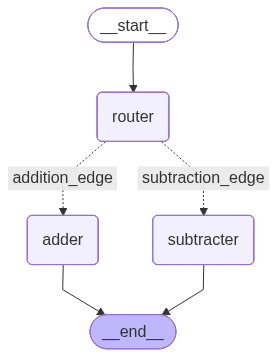

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
result = app.invoke({"num1": 5, "num2": 3, "operation": "+"})
result

{'num1': 5, 'num2': 3, 'operation': '+', 'finalNum': 8}

In [14]:
initial_state = AgentState(num1 = 10, num2 = 3, operation="-")
print(app.invoke(initial_state))

{'num1': 10, 'num2': 3, 'operation': '-', 'finalNum': 7}
